In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv('./train_6x6_mazes.csv')
df.head()

,input_sequence,output_path,maze_type
0,"['<ADJLIST_START>', '(3,5)', '<-->', '(2,5)', ...","['(0,3)', '(0,4)', '(1,4)', '(1,5)', '(2,5)', ...",forkless
1,"['<ADJLIST_START>', '(5,4)', '<-->', '(5,3)', ...","['(3,0)', '(2,0)', '(2,1)', '(2,2)', '(1,2)', ...",forkless
2,"['<ADJLIST_START>', '(5,3)', '<-->', '(4,3)', ...","['(2,2)', '(3,2)', '(3,3)', '(3,4)', '(4,4)', ...",forked
3,"['<ADJLIST_START>', '(2,0)', '<-->', '(1,0)', ...","['(5,0)', '(5,1)', '(5,2)', '(4,2)', '(4,1)', ...",forked
4,"['<ADJLIST_START>', '(3,0)', '<-->', '(3,1)', ...","['(0,0)', '(1,0)', '(2,0)', '(3,0)', '(3,1)', ...",forkless


In [4]:
type(df['input_sequence'].iloc[0])

str

In [11]:
inp_tokens = eval(df['input_sequence'].iloc[0])
out_tokens = eval(df['output_path'].iloc[0])

print(inp_tokens+out_tokens)

['<ADJLIST_START>', '(3,5)', '<-->', '(2,5)', ';', '(3,2)', '<-->', '(3,3)', ';', '(3,4)', '<-->', '(3,3)', ';', '(0,4)', '<-->', '(1,4)', ';', '(2,3)', '<-->', '(2,4)', ';', '(1,5)', '<-->', '(2,5)', ';', '(3,4)', '<-->', '(3,5)', ';', '(0,1)', '<-->', '(0,0)', ';', '(0,2)', '<-->', '(0,1)', ';', '(3,2)', '<-->', '(2,2)', ';', '(2,3)', '<-->', '(1,3)', ';', '(1,4)', '<-->', '(1,5)', ';', '(1,0)', '<-->', '(0,0)', ';', '(1,3)', '<-->', '(1,2)', ';', '(1,2)', '<-->', '(2,2)', ';', '(0,4)', '<-->', '(0,3)', ';', '(0,2)', '<-->', '(0,3)', ';', '<ADJLIST_END>', '<ORIGIN_START>', '(0,3)', '<ORIGIN_END>', '<TARGET_START>', '(1,3)', '<TARGET_END>', '<PATH_START>', '(0,3)', '(0,4)', '(1,4)', '(1,5)', '(2,5)', '(3,5)', '(3,4)', '(3,3)', '(3,2)', '(2,2)', '(1,2)', '(1,3)', '<PATH_END>']


In [7]:
def parse_coords(s):
    nums = re.findall(r"-?\d+", s)
    return tuple(map(int, nums)) if len(nums) == 2 else None

def extract_between(tag, text):
    """Accepts many tag styles: <TAG_START>, <TAG START>, <TAG-START>, <TAGSTART>, etc."""
    patterns = [
        rf"<\s*{tag}\s*[_\-\s]?\s*START\s*>(.*?)<\s*{tag}\s*[_\-\s]?\s*END\s*>",
        rf"<\s*{tag}START\s*>(.*?)<\s*{tag}END\s*>",
        rf"<\s*{tag}\s*START\s*>(.*?)<\s*{tag}\s*END\s*>",
        rf"<\s*{tag.replace(' ', '_')}\s*START\s*>(.*?)<\s*{tag.replace(' ', '_')}\s*END\s*>",
    ]
    for p in patterns:
        m = re.search(p, text, re.S | re.I)
        if m:
            return m.group(1).strip()
    raise ValueError(f"Could not find section for tag '{tag}'. Tried multiple patterns.")

def plot_maze(tokens):
    text = " ".join(tokens)
    adj_section = extract_between("ADJLIST", text)
    origin_section = extract_between("ORIGIN", text)
    target_section = extract_between("TARGET", text)
    path_section = extract_between("PATH", text)

    origin = parse_coords(origin_section)
    target = parse_coords(target_section)

    # parse edges like "(r,c) <--> (r2,c2)"
    edge_matches = re.findall(r"\(\s*-?\d+\s*,\s*-?\d+\s*\)\s*<-->\s*\(\s*-?\d+\s*,\s*-?\d+\s*\)", adj_section)
    edges = []
    for em in edge_matches:
        coords = re.findall(r"\(\s*-?\d+\s*,\s*-?\d+\s*\)", em)
        a = parse_coords(coords[0])
        b = parse_coords(coords[1])
        edges.append((a, b))

    # parse path coordinates (supports parenthesized coords)
    path = [parse_coords(p) for p in re.findall(r"\(\s*-?\d+\s*,\s*-?\d+\s*\)", path_section)]
    if not path:
        # fallback: "r,c" tokens without parentheses
        nums = re.findall(r"-?\d+\s*,\s*-?\d+", path_section)
        path = [tuple(map(int, re.findall(r"-?\d+", s))) for s in nums]

    if not edges:
        raise ValueError("No edges found in adjacency list. Ensure format '(r,c) <--> (r2,c2)'.")

    # --------------------------
    # Grid size (cells indexed with (0,0) = top-left)
    # --------------------------
    all_nodes = {n for e in edges for n in e if n is not None}
    all_nodes.update([origin, target])
    all_nodes.update([p for p in path if p is not None])
    rows = 6
    cols = 6


    vertical_walls = np.ones((rows, cols + 1), dtype=bool)
    horizontal_walls = np.ones((rows + 1, cols), dtype=bool)

    for (r1, c1), (r2, c2) in edges:
        if r1 == r2:
            # same row, adjacent columns -> remove vertical wall between them
            c_between = min(c1, c2) + 1  # column index of the vertical segment between c and c+1
            vertical_walls[r1, c_between] = False
        elif c1 == c2:
            # same column, adjacent rows -> remove horizontal wall between them
            r_between = min(r1, r2) + 1  # row index of horizontal segment between r and r+1
            horizontal_walls[r_between, c1] = False
        else:
            # diagonal or invalid — ignore, but warn
            print(f"Warning: non-grid edge {(r1,c1)} <--> {(r2,c2)} ignored")


    fig, ax = plt.subplots(figsize=(4, 4))
    ax.set_aspect('equal')

    # Draw a full light-gray grid (every cell border)
    for r in range(rows):
        for c in range(cols):
            x0, x1 = c, c + 1
            y_top = rows - r
            y_bot = rows - r - 1
            ax.plot([x0, x1], [y_top, y_top], color='lightgray', lw=2)   # top
            ax.plot([x0, x1], [y_bot, y_bot], color='lightgray', lw=2)   # bottom
            ax.plot([x0, x0], [y_bot, y_top], color='lightgray', lw=2)   # left
            ax.plot([x1, x1], [y_bot, y_top], color='lightgray', lw=2)   # right

    # Draw vertical walls (black) using vertical_walls[r,c]
    for r in range(rows):
        for c in range(cols + 1):
            if vertical_walls[r, c]:
                x = c
                y_top = rows - r
                y_bot = rows - r - 1
                ax.plot([x, x], [y_bot, y_top], color='black', lw=5, solid_capstyle='butt')

    # Draw horizontal walls (black)
    for r in range(rows + 1):
        for c in range(cols):
            if horizontal_walls[r, c]:
                y = rows - r
                ax.plot([c, c + 1], [y, y], color='black', lw=5, solid_capstyle='butt')

    shade_path_cells = True
    if shade_path_cells and path:
        for (r, c) in path:
            # rectangle corners in plot coords
            x0, x1 = c, c + 1
            y_top = rows - r
            y_bot = rows - r - 1
            rect = plt.Rectangle((x0, y_bot), 1, 1, facecolor=(1, 0.9, 0.9), edgecolor=None, zorder=0)
            ax.add_patch(rect)

    # Plot path line and markers (convert (r,c) top-left -> matplotlib coords)
    if path:
        path_x = [c + 0.5 for (r, c) in path]
        path_y = [rows - r - 0.5 for (r, c) in path]
        ax.plot(path_x, path_y, linestyle='--', linewidth=2, color='red', zorder=4)
        ax.scatter(path_x[0], path_y[0], c='red', s=80, marker='o', zorder=5)  # start
        ax.scatter(path_x[-1], path_y[-1], c='red', s=80, marker='x', zorder=5)  # goal
    else:
        # if no path, still mark origin/target
        ox, oy = origin[1] + 0.5, rows - origin[0] - 0.5
        tx, ty = target[1] + 0.5, rows - target[0] - 0.5
        ax.scatter(ox, oy, c='red', s=80, marker='o', zorder=5)
        ax.scatter(tx, ty, c='red', s=80, marker='x', zorder=5)

    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.set_xticks(np.arange(cols))
    ax.set_yticks(np.arange(rows))
    plt.yticks([]) 
    ax.set_xlabel("col")
    ax.set_ylabel("row")
    plt.tight_layout()
    plt.show()


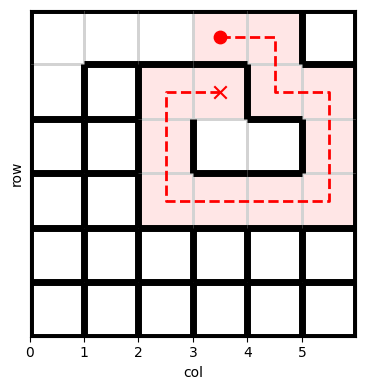

In [12]:
plot_maze(inp_tokens+out_tokens)